# Анализ перевозок грузов по видам транспорта в России (2000–2024)

## Описание
Ноутбук содержит анализ двух таблиц из файла PerevGruz.xlsx:
1. **Лист 1**: Перевозки грузов по видам транспорта (млн тонн).
2. **Лист 2**: Структура перевозок грузов по видам транспорта (процент).

Включает:
- загрузку данных с обоих листов;
- построение графиков по объёмам перевозок;
- анализ структуры (доли) перевозок;
- сравнительный анализ тенденций.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Настройки отображения графиков в Jupyter
%matplotlib inline

# ====== ЛИСТ 1: Объёмы перевозок (млн тонн) ======
data1 = {
    'Год': [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024],
    'железнодорожный': [1046.8, 1057.5, 1083.7, 1160.9, 1221.2, 1273.3, 1311.6, 1344.6, 1304.4, 1108.8, 1312.0, 1381.7, 1421.1, 1381.2, 1375.4, 1329.0, 1325.2, 1384.3, 1410.9, 1398.6, 1358.5, 1403.9, 1351.3, 1365.2, 1306.1],
    'автомобильный': [5878.4, 6125.3, 6347.7, 6468.1, 6567.8, 6684.6, 6753.3, 6861.4, 6893.1, 5240.5, 5236.4, 5663.1, 5841.6, 5635.3, 5416.7, 5356.7, 5396.8, 5403.9, 5544.4, 5735.3, 5404.7, 5581.7, 6210.6, 6491.2, 6775.9],
    'газопроводный': [511.2, 508.8, 513.8, 544.5, 555.1, 565.8, 581.1, 571.6, 578.6, 480.0, 536.6, 555.1, 541.1, 537.5, 512.0, 493.0, 509.4, 548.8, 566.4, 550.9, 511.6, 574.6, 484.3, np.nan, np.nan],
    'нефтепроводный': [294.6, 319.7, 359.8, 404.3, 441.5, 454.1, 460.8, 461.8, 456.4, 474.4, 491.7, 543.8, 523.4, 524.6, 532.1, 543.3, 543.4, 553.4, 561.1, 567.7, 509.5, 523.9, 544.4, np.nan, np.nan],
    'нефтепродуктопроводный': [23.1, 24.9, 25.7, 27.6, 27.6, 28.2, 28.4, 28.7, 31.6, 30.6, 33.2, 32.0, 32.0, 33.1, 34.0, 34.7, 35.2, 36.1, 41.8, 40.5, 40.4, 42.9, 44.1, np.nan, np.nan],
    'морской': [35.4, 33.8, 37.3, 35.7, 29.1, 26.0, 25.4, 28.1, 35.2, 37.4, 37.0, 34.0, 18.3, 16.7, 15.8, 18.8, 24.6, 26.4, 23.2, 23.2, 24.7, 23.4, 27.6, 33.2, 31.9],
    'внутренний_водный': [116.8, 129.5, 118.7, 125.8, 135.0, 134.2, 139.2, 153.4, 150.8, 96.9, 102.4, 126.2, 140.5, 134.9, 119.1, 121.4, 118.0, 118.5, 116.2, 108.2, 109.0, 110.5, 116.4, 109.3, 105.4],
    'воздушный': [0.8, 0.9, 0.9, 0.8, 0.9, 0.8, 0.9, 1.0, 1.0, 0.9, 1.1, 1.2, 1.2, 1.2, 1.3, 1.0, 1.1, 1.3, 1.3, 1.3, 1.3, 1.6, 0.7, 0.6, 0.6]
}

df1 = pd.DataFrame(data1)

# ====== ЛИСТ 2: Структура перевозок (%) ======
data2 = {
    'Год': [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024],
    'железнодорожный': [13.2, 12.9, 12.8, 13.2, 13.6, 13.9, 14.1, 14.2, 13.8, 14.8, 16.9, 16.6, 16.7, 16.7, 17.2, 16.8, 16.7, 17.1, 17.1, 16.6, 17.1, 17.0, 15.5, 15.1, 14.1],
    'воздушный': [0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.02, 0.01, 0.01, 0.02, 0.02, 0.02, 0.02, 0.02, 0.01, 0.01, 0.01],
    'автомобильный': [74.4, 74.7, 74.8, 73.9, 73.2, 73.0, 72.6, 72.7, 72.9, 70.2, 67.6, 67.9, 68.5, 68.2, 67.6, 67.8, 67.8, 67.0, 67.1, 68.0, 67.9, 67.6, 70.7, 71.6, 73.0],
    'водный_транспорт': [1.9, 2.0, 1.8, 1.8, 1.8, 1.7, 1.8, 1.9, 2.0, 1.8, 1.8, 1.9, 1.9, 1.8, 1.7, 1.8, 1.8, 1.8, 1.7, 1.6, 1.7, 1.6, 1.6, 1.6, 1.4],
    'трубопроводный': [10.5, 10.4, 10.6, 11.1, 11.4, 11.4, 11.5, 11.2, 11.3, 13.2, 13.7, 13.6, 12.9, 13.3, 13.5, 13.6, 13.7, 14.1, 14.1, 13.8, 13.3, 13.8, 12.2, 11.7, 11.5]
}

df2 = pd.DataFrame(data2)

print("Лист 1 (объёмы перевозок, млн тонн):")
print(df1.head())
print("\nЛист 2 (структура перевозок, %):")
print(df2.head())


Лист 1 (объёмы перевозок, млн тонн):
    Год  железнодорожный  автомобильный  газопроводный  нефтепроводный  \
0  2000           1046.8         5878.4          511.2           294.6   
1  2001           1057.5         6125.3          508.8           319.7   
2  2002           1083.7         6347.7          513.8           359.8   
3  2003           1160.9         6468.1          544.5           404.3   
4  2004           1221.2         6567.8          555.1           441.5   

   нефтепродуктопроводный  морской  внутренний_водный  воздушный  
0                    23.1     35.4              116.8        0.8  
1                    24.9     33.8              129.5        0.9  
2                    25.7     37.3              118.7        0.9  
3                    27.6     35.7              125.8        0.8  
4                    27.6     29.1              135.0        0.9  

Лист 2 (структура перевозок, %):
    Год  железнодорожный  воздушный  автомобильный  водный_транспорт  \
0  2000   

In [2]:
print("=== Обзор Листа 1 ===")
print(df1.describe())
print("\n=== Обзор Листа 2 ===")
print(df2.describe())


=== Обзор Листа 1 ===
               Год  железнодорожный  автомобильный  газопроводный  \
count    25.000000        25.000000      25.000000      23.000000   
mean   2012.000000      1296.688000    5980.580000     536.165217   
std       7.359801       115.452553     572.227786      30.909349   
min    2000.000000      1046.800000    5236.400000     480.000000   
25%    2006.000000      1273.300000    5416.700000     511.400000   
50%    2012.000000      1329.000000    5841.600000     541.100000   
75%    2018.000000      1381.200000    6491.200000     560.450000   
max    2024.000000      1421.100000    6893.100000     581.100000   

       нефтепроводный  нефтепродуктопроводный    морской  внутренний_водный  \
count       23.000000               23.000000  25.000000          25.000000   
mean       482.160870               32.886957  28.088000         122.252000   
std         76.575404                5.936812   6.748723          14.587584   
min        294.600000               23.1

## График 1. Динамика всех видов транспорта (абсолютные объёмы)

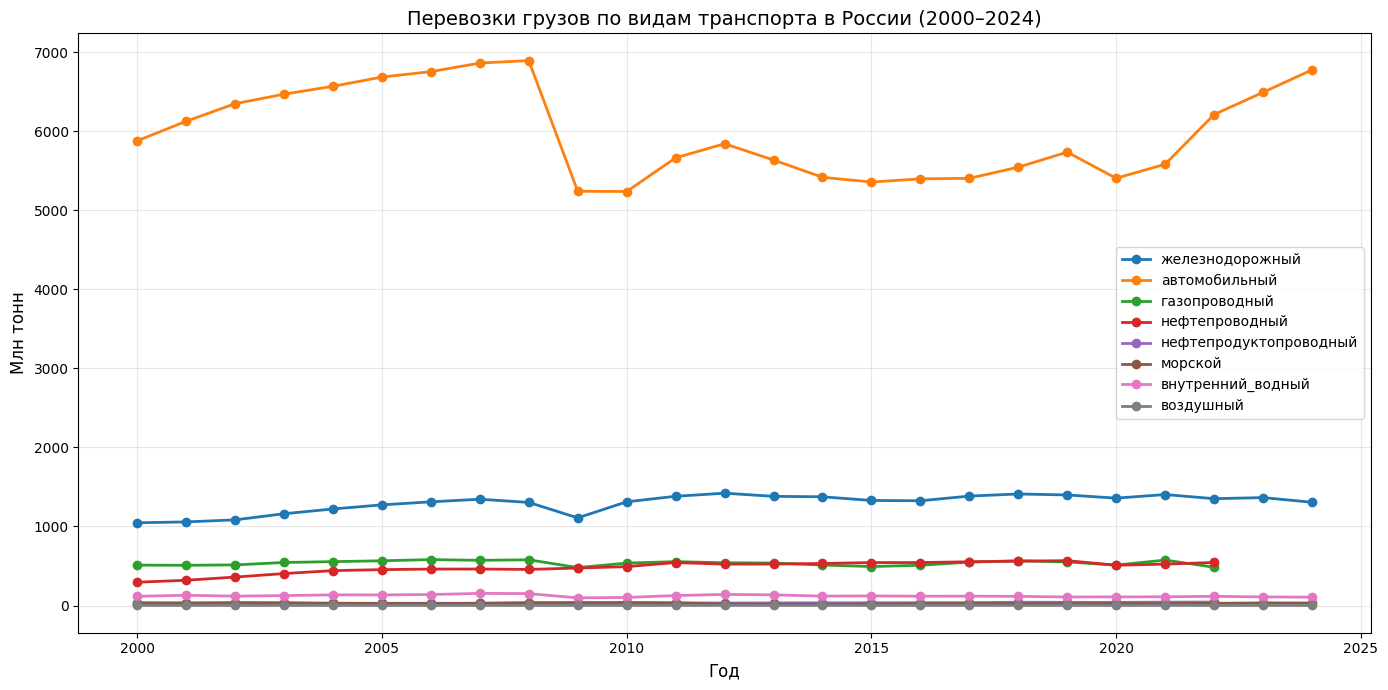

In [3]:
# График 1. Динамика всех видов транспорта (абсолютные объёмы)
plt.figure(figsize=(14, 7))
for col in df1.columns:
    if col != 'Год':
        plt.plot(df1['Год'], df1[col], marker='o', label=col, linewidth=2)

plt.title('Перевозки грузов по видам транспорта в России (2000–2024)', fontsize=14)
plt.xlabel('Год', fontsize=12)
plt.ylabel('Млн тонн', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Выводы по График 1:
- **Автомобильный транспорт** — абсолютный лидер, но показывает волатильность (кризис 2009 г.).
- **Железнодорожный транспорт** — более стабилен, занимает второе место.
- **Трубопроводные виды** (газ, нефть, нефтепродукты) демонстрируют относительно плавную динамику.


## График 2. Структура перевозок в процентах

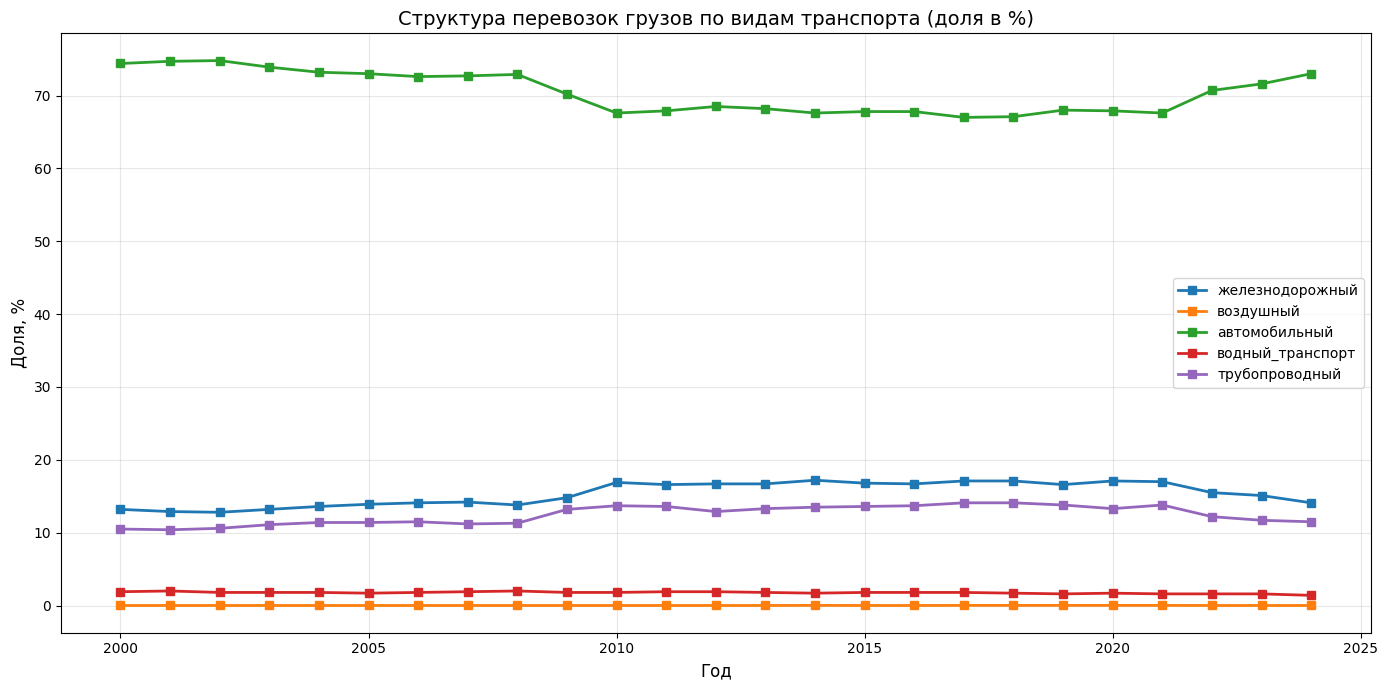

In [4]:
# График 2. Структура перевозок в процентах (Лист 2)
plt.figure(figsize=(14, 7))
for col in df2.columns:
    if col != 'Год':
        plt.plot(df2['Год'], df2[col], marker='s', label=col, linewidth=2)

plt.title('Структура перевозок грузов по видам транспорта (доля в %)', fontsize=14)
plt.xlabel('Год', fontsize=12)
plt.ylabel('Доля, %', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Выводы по График 2:
- **Автомобильный транспорт** колебается между 67–74% от всех перевозок, заметно вырос в 2024 г.
- **Железнодорожный транспорт** вырос с 13% в 2000 г. до максимума ~17% в 2010–2018 гг., затем снизился.
- **Трубопроводный транспорт** вырос с 10.5% в 2000 г. до максимума 14.1% в 2017–2018 гг.
- **Водный транспорт** остаётся минимальным (1.4–2%), воздушный — практически незначителен (0.01%).


## График 3. Сравнение объёмов и структуры (2021 год)

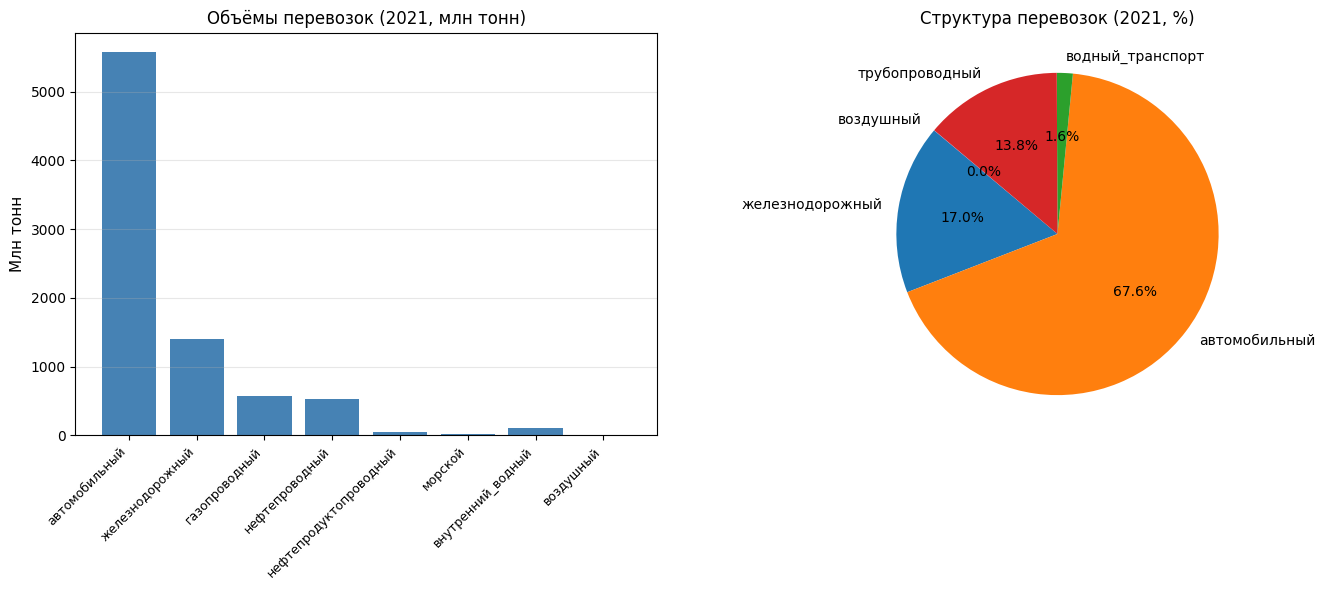

In [5]:
# График 3. Сравнение объёмов и структуры: пример на 2021 год
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Слева: абсолютные объёмы
row_2021_abs = df1[df1['Год'] == 2021].iloc[0]
labels_abs = ['автомобильный', 'железнодорожный', 'газопроводный', 'нефтепроводный',
              'нефтепродуктопроводный', 'морской', 'внутренний_водный', 'воздушный']
values_abs = [row_2021_abs[l] for l in labels_abs]

ax1.bar(range(len(labels_abs)), values_abs, color='steelblue')
ax1.set_title('Объёмы перевозок (2021, млн тонн)', fontsize=12)
ax1.set_ylabel('Млн тонн', fontsize=11)
ax1.set_xticks(range(len(labels_abs)))
ax1.set_xticklabels(labels_abs, rotation=45, ha='right', fontsize=9)
ax1.grid(axis='y', alpha=0.3)

# Справа: структура в процентах
row_2021_pct = df2[df2['Год'] == 2021].iloc[0]
labels_pct = ['железнодорожный', 'автомобильный', 'водный_транспорт', 'трубопроводный', 'воздушный']
values_pct = [row_2021_pct[l] for l in labels_pct]

ax2.pie(values_pct, labels=labels_pct, autopct='%1.1f%%', startangle=140)
ax2.set_title('Структура перевозок (2021, %)', fontsize=12)

plt.tight_layout()
plt.show()


### Выводы по График 3:
- В 2021 году **автомобильный транспорт** обеспечил 67.6% от всех перевозок (5581.7 млн тонн).
- **Железнодорожный транспорт** — 17% (1403.9 млн тонн), хотя по объёмам это значительные величины.
- **Трубопроводный транспорт** в совокупности — ~13.8% от структуры перевозок.


## График 4. Динамика доли автомобильного транспорта

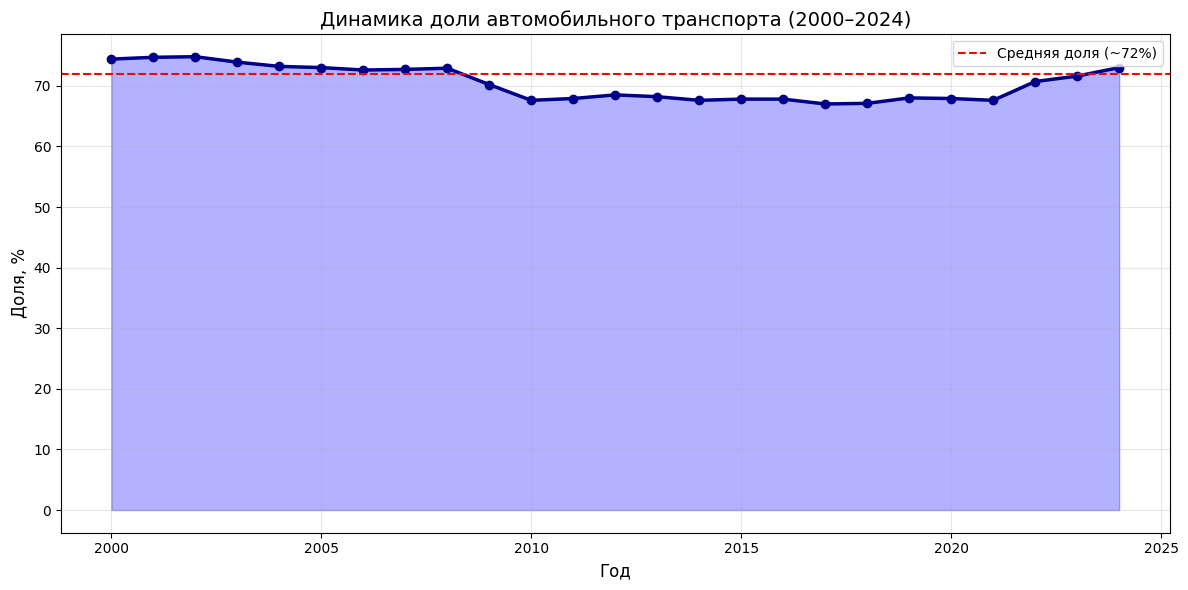

In [6]:
# График 4. Изменение доли автомобильного транспорта
plt.figure(figsize=(12, 6))
plt.plot(df2['Год'], df2['автомобильный'], marker='o', linewidth=2.5, markersize=6, color='darkblue')
plt.fill_between(df2['Год'], df2['автомобильный'], alpha=0.3, color='blue')

plt.title('Динамика доли автомобильного транспорта (2000–2024)', fontsize=14)
plt.xlabel('Год', fontsize=12)
plt.ylabel('Доля, %', fontsize=12)
plt.grid(True, alpha=0.3)
plt.axhline(y=72, color='red', linestyle='--', linewidth=1.5, label='Средняя доля (~72%)')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()


### Выводы по График 4:
- Доля автомобильного транспорта снизилась с **74.4% в 2000** г. до минимума **67% в 2017** г.
- Затем произошёл **восстановительный рост**: 67.6% (2021) → 73% (2024).
- Кризис 2009 года сильно повлиял на структуру, хотя автомобильный транспорт остался лидером.


## График 5. Тренды железнодорожного и трубопроводного транспорта

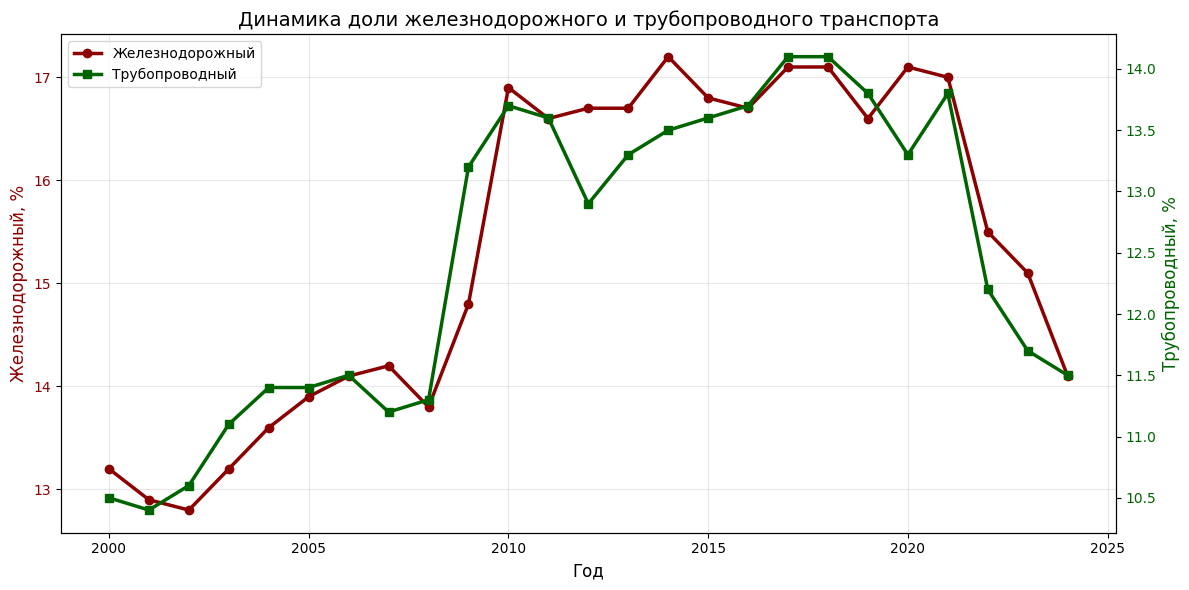

In [7]:
# График 5. Тренды железнодорожного и трубопроводного транспорта
plt.figure(figsize=(12, 6))
ax1 = plt.gca()
ax2 = ax1.twinx()

line1 = ax1.plot(df2['Год'], df2['железнодорожный'], marker='o', color='darkred', linewidth=2.5, label='Железнодорожный')
line2 = ax2.plot(df2['Год'], df2['трубопроводный'], marker='s', color='darkgreen', linewidth=2.5, label='Трубопроводный')

ax1.set_xlabel('Год', fontsize=12)
ax1.set_ylabel('Железнодорожный, %', fontsize=12, color='darkred')
ax2.set_ylabel('Трубопроводный, %', fontsize=12, color='darkgreen')
ax1.tick_params(axis='y', labelcolor='darkred')
ax2.tick_params(axis='y', labelcolor='darkgreen')
ax1.grid(True, alpha=0.3)

plt.title('Динамика доли железнодорожного и трубопроводного транспорта', fontsize=14)

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()


### Выводы по График 5:
- **Железнодорожный транспорт**: рос с 13.2% (2000) до ~17% (2010–2018), затем снизился до 14.1% (2024).
- **Трубопроводный транспорт**: вырос с 10.5% (2000) до пика 14.1% (2017–2018), затем слегка снизился.
- Оба вида показывают увеличение доли после 2009 года, подчеркивая их важность в логистике.


## График 6. Сравнение структуры: 2000 vs 2024

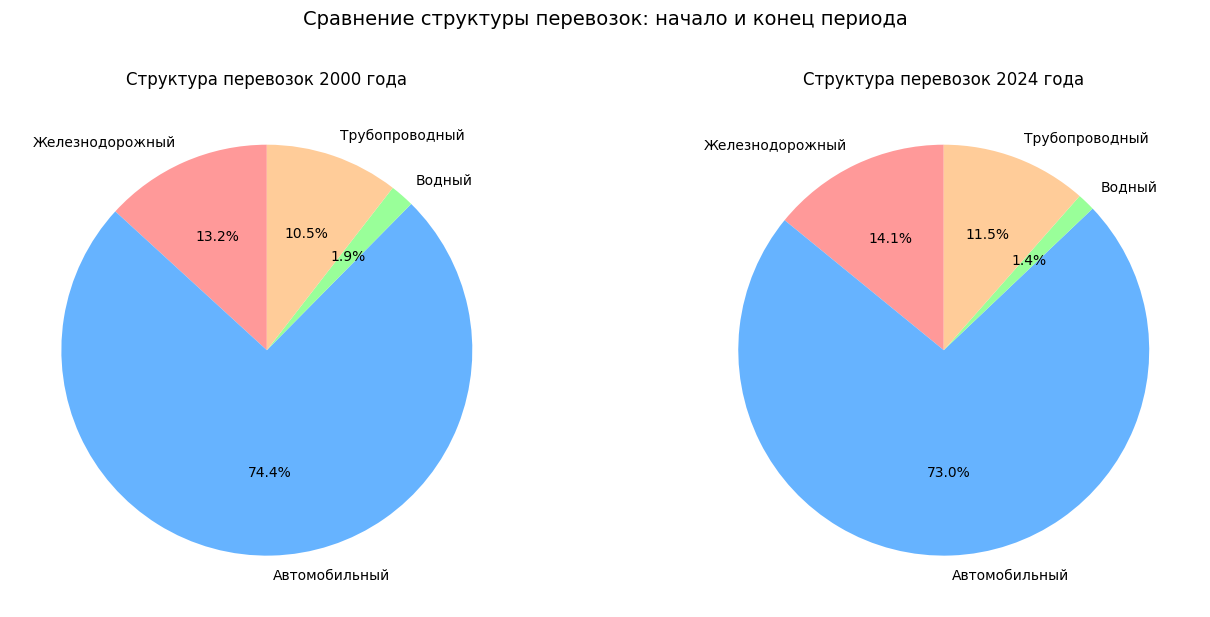

In [8]:
# График 6. Сравнение 2000 и 2024 годов
years_compare = [2000, 2024]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# 2000 год
row_2000 = df2[df2['Год'] == 2000].iloc[0]
labels_chart = ['Железнодорожный', 'Автомобильный', 'Водный', 'Трубопроводный']
values_2000 = [row_2000['железнодорожный'], row_2000['автомобильный'], row_2000['водный_транспорт'], row_2000['трубопроводный']]

ax1.pie(values_2000, labels=labels_chart, autopct='%1.1f%%', startangle=90, colors=['#ff9999', '#66b3ff', '#99ff99', '#ffcc99'])
ax1.set_title('Структура перевозок 2000 года', fontsize=12)

# 2024 год
row_2024 = df2[df2['Год'] == 2024].iloc[0]
values_2024 = [row_2024['железнодорожный'], row_2024['автомобильный'], row_2024['водный_транспорт'], row_2024['трубопроводный']]

ax2.pie(values_2024, labels=labels_chart, autopct='%1.1f%%', startangle=90, colors=['#ff9999', '#66b3ff', '#99ff99', '#ffcc99'])
ax2.set_title('Структура перевозок 2024 года', fontsize=12)

plt.suptitle('Сравнение структуры перевозок: начало и конец периода', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


### Выводы по График 6:
- **2000 год**: Автомобильный (74.4%) доминировал, Железнодорожный (13.2%), Трубопроводный (10.5%).
- **2024 год**: Автомобильный вырос до 73%, Железнодорожный снизился до 14.1%, Трубопроводный до 11.5%.
- Структура перевозок остаётся довольно консервативной, но видны тенденции:
  - Восстановление доли автомобильного транспорта после кризиса 2009 г.
  - Рост значимости железнодорожного транспорта (особенно 2010–2018).


## Итоговая таблица ключевых показателей

In [9]:
# Итоговая таблица сравнения ключевых показателей
summary_years = [2000, 2008, 2009, 2010, 2015, 2021, 2024]

summary_data = []
for year in summary_years:
    row1 = df1[df1['Год'] == year].iloc[0]
    row2 = df2[df2['Год'] == year].iloc[0]

    summary_data.append({
        'Год': int(year),
        'Авто объём (млн)': row1['автомобильный'],
        'Авто доля (%)': row2['автомобильный'],
        'ЖД объём (млн)': row1['железнодорожный'],
        'ЖД доля (%)': row2['железнодорожный'],
        'Трубо объём (млн)': row1['газопроводный'] + row1['нефтепроводный'] + row1['нефтепродуктопроводный'],
        'Трубо доля (%)': row2['трубопроводный']
    })

summary_df = pd.DataFrame(summary_data)
print("\n=== ИТОГОВАЯ ТАБЛИЦА ===")
print(summary_df.to_string(index=False))



=== ИТОГОВАЯ ТАБЛИЦА ===
 Год  Авто объём (млн)  Авто доля (%)  ЖД объём (млн)  ЖД доля (%)  Трубо объём (млн)  Трубо доля (%)
2000            5878.4           74.4          1046.8         13.2              828.9            10.5
2008            6893.1           72.9          1304.4         13.8             1066.6            11.3
2009            5240.5           70.2          1108.8         14.8              985.0            13.2
2010            5236.4           67.6          1312.0         16.9             1061.5            13.7
2015            5356.7           67.8          1329.0         16.8             1071.0            13.6
2021            5581.7           67.6          1403.9         17.0             1141.4            13.8
2024            6775.9           73.0          1306.1         14.1                NaN            11.5
